# 🚀 Day 5 — Matrix Factorization / SVD

Today is a BIG jump.

Until now:

Day 3 → similar users

Day 4 → similar movies


Both depended on:

direct correlations

Today:

system learns hidden patterns automatically

This is the beginning of:

modern recommender systems

embeddings

latent features

Netflix-style recommendation



---

🧠 First Understand WHY We Need Something Better

Problem with Day 3 & 4:

sparse data

noisy correlations

weak overlaps

scalability issues


Example:

two users may never watch same movie

But:

both may secretly like:

dark sci-fi

psychological thrillers

slow emotional movies



Correlation methods miss this.


---

🎯 CORE IDEA OF TODAY

Instead of:

manually comparing ratings

we let ML discover:

hidden preference dimensions

These are called:

Latent Features


---

🎬 Example of Latent Features

Movies may secretly contain hidden dimensions like:

Movie	Action	Romance	Comedy	Sci-Fi

Batman	High	Low	Low	Medium
Titanic	Low	High	Low	Low
Interstellar	Medium	Medium	Low	High


BUT:

dataset never explicitly gives these

model LEARNS them automatically


That’s the magic.


---

🧠 HUGE CONCEPT TODAY

Matrix factorization converts:

User × Movie Matrix

into:

User Features × Movie Features


---

🔥 Original Matrix

User	Batman	Titanic	Matrix

U1	5	1	5
U2	4	2	5
U3	1	5	1


Sparse and huge.


---

🚀 Model Learns Hidden Vectors

Instead:

User Embeddings

User	Action Lover	Romance Lover

U1	0.9	0.1
U2	0.8	0.2
U3	0.1	0.9


Movie Embeddings

Movie	Action	Romance

Batman	0.9	0.1
Titanic	0.1	0.9


Now recommendations become:

vector matching

THIS is modern recommendation systems.


---

🎯 Why This Is Powerful

Now system can recommend:

movies users never overlapped on

because hidden taste patterns are learned.

This solves:

sparsity better

scalability better

noisy correlations better



---

🚀 TODAY’S IMPLEMENTATION

We’ll use:

SVD (Singular Value Decomposition)

using:

Surprise


---

🔥 STEP 1 — Install Surprise

If not installed:

pip install scikit-surprise


---

🚀 STEP 2 — Load Dataset

from surprise import Dataset
from surprise import Reader
import pandas as pd

ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']

ratings = pd.read_csv(
    '../data/ml-100k/u.data',
    sep='\t',
    names=ratings_cols
)

ratings.head()


---

🚀 STEP 3 — Prepare Data For Surprise

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    ratings[['user_id', 'movie_id', 'rating']],
    reader
)


---

❓WHY This Format?

Surprise expects:

(user, item, rating)

triplets.

Because internally it builds:

matrices

latent vectors

embeddings



---

🚀 STEP 4 — Train/Test Split

from surprise.model_selection import train_test_split

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)


---

🚀 STEP 5 — Train SVD Model

from surprise import SVD

model = SVD()

model.fit(trainset)


---

🧠 WHAT IS HAPPENING HERE?

The model is learning:

hidden user preferences

hidden movie characteristics

latent embeddings


NOT direct correlations anymore.


---

🚀 STEP 6 — Make Predictions

Example:

prediction = model.predict(
    uid=1,
    iid=50
)

print(prediction)

Meaning:

Predict how much User1 may like Movie50


---

🚀 STEP 7 — Understand Output

You’ll see:

user: 1
item: 50
estimated rating: 4.2

Meaning:

model thinks user will probably rate movie 50 around 4.2


---

🚀 STEP 8 — Evaluate Model

from surprise import accuracy

predictions = model.test(testset)

accuracy.rmse(predictions)


---

🧠 WHAT IS RMSE?

Root Mean Squared Error.

Measures:

how close predicted ratings are to actual ratings

Lower:

better


---

🎯 WHY SVD IS A HUGE DEAL

Because this is the foundation of:

Netflix Prize models

embedding systems

recommendation engines

latent representation learning


This is REAL recommendation ML.


---

🔥 IMPORTANT CONCEPT

Previous days:

explicit similarity

Today:

implicit hidden similarity

The model DISCOVERS patterns itself.


---

🧠 ENTIRE DAY 5 IN ONE SENTENCE

Matrix factorization means:

Learn hidden user tastes
and hidden movie characteristics automatically.

That’s all.


---

🚀 Homework / Experiments


---

1️⃣ Try Different Users & Movies

model.predict(uid=5, iid=100)

Observe:

estimated ratings vary



---

2️⃣ Observe Cold Start Problem

Try:

new user

Predictions weak.

Because:

no learned embedding


---

3️⃣ Compare With Day 4

Notice:

recommendations now smoother

fewer weird correlations

handles sparsity better



---

🧠 BIG INDUSTRY INSIGHT

Modern AI recommendation systems are basically:

large embedding systems

TikTok, YouTube, Netflix:

all heavily embedding-driven.


Today you entered that world.



# What Are Latent Features?

Definition: Latent features (or latent variables) are hidden representations of data learned by models. They are not explicitly provided but are inferred during training.

Purpose: They capture underlying patterns, relationships, or structures in the data that raw features don’t directly show.

Example: In a recommender system, latent features might represent abstract concepts like “user preference for action movies” or “romantic theme intensity in films”—even though these aren’t explicit columns in the dataset.

# Singular Value Decomposition ( SVD )

In [1]:
pip install scikit-surprise

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: C:\Users\Mugundhan\ML_Learning\recommendation_system\venv_ml\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)


C:\Users\Mugundhan\ML_Learning\recommendation_system\venv_ml\Scripts\python.exe


pip install "numpy<2.0"

pip uninstall scikit-surprise -y

In [3]:
# Load dataset

from surprise import Dataset, Reader, SVD, accuracy

import pandas as pd

from surprise.model_selection import train_test_split

import matplotlib.pyplot as plt

In [4]:
ratings_cols = [ 'user_id', 'movie_id', 'rating', 'timestamp' ]

ratings = pd.read_csv ( '../data/ml-100k/u.data', sep = '\t', names = ratings_cols )

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
# Prepare data for surprise

reader = Reader ( rating_scale = ( 1, 5 ) )  

data = Dataset.load_from_df ( ratings[ [ 'user_id', 'movie_id', 'rating' ] ], reader )

# Surprise expects ( user, item, rating )

# internally it builds -> matrices, latents vectors, embeddings 

In [6]:
# Train test split

trainset, testset = train_test_split ( data, test_size = 0.2, random_state = 42 )


In [7]:
# Train SVD model

model = SVD()

model.fit ( trainset )

# model is learning hidden user preferences, hidden movie characteristics, latent embeddings

# no direct cor relation

In [8]:
# Make Predictions

prediction = model.predict ( uid = 1, iid = 50 ) # predicting How user with id - 1 may like movie - 50

print (prediction)

user: 1          item: 50         r_ui = None   est = 4.80   {'was_impossible': False}


In [9]:
# Evaluate

predictions = model.test ( testset )

accuracy.rmse ( predictions )

# RMSE -> Root mean sq error -> Lower = better

RMSE: 0.9393


0.9393476965835197

# Complete Explanation: Surprise Library - Recommendation System

## Line-by-Line Breakdown

---

### 📦 Imports

```python
from surprise import Dataset, Reader, SVD, accuracy
import pandas as pd
from surprise.model_selection import train_test_split
```

| Import | What it is |
|---|---|
| `Dataset` | Surprise's internal data container — not a pandas df |
| `Reader` | Tells Surprise how to interpret your rating scale |
| `SVD` | Matrix Factorization algorithm (the core ML model) |
| `accuracy` | Surprise's own metrics module (has RMSE, MAE) |
| `train_test_split` | Surprise's own splitter — different from sklearn's |

> **Why separate imports from sklearn?** Because Surprise works with **user-item interaction data**, which has a completely different structure than sklearn's feature-matrix `X` and label-vector `y`.

---

### 📂 Loading the Dataset

```python
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=ratings_cols)
```

- `ml-100k` is the **MovieLens 100K dataset** — 100,000 ratings from 943 users on 1,682 movies
- The file `u.data` is **tab-separated** with no header, so you manually name the columns
- `timestamp` is loaded but **never used** — it's just in the raw file

The dataframe looks like:

| user_id | movie_id | rating | timestamp |
|---|---|---|---|
| 196 | 242 | 3 | 881250949 |
| 186 | 302 | 3 | 891717742 |

---

### 📖 Reader — The Bridge Between Pandas and Surprise

```python
reader = Reader(rating_scale=(1, 5))
```

**Why do we need this?**

Surprise doesn't know that your numbers mean "ratings from 1 to 5". The `Reader` acts as a **translator/contract** that tells Surprise:
- Minimum possible rating = 1
- Maximum possible rating = 5

This matters because:
- SVD uses this scale for **clamping predictions** (won't predict 6.2 or -0.3)
- It normalizes internally during matrix factorization

---

### 🔄 Converting Pandas DataFrame → Surprise Dataset

```python
data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)
```

**Why convert to Surprise's Dataset format?**

| Pandas DataFrame | Surprise Dataset |
|---|---|
| General table — rows and columns | Specialized interaction matrix format |
| No concept of "users" or "items" | Knows who rated what |
| Can't do train/test split for CF | Built-in CF-aware splitting |
| No rating scale awareness | Knows scale = (1,5) |

You pass **exactly 3 columns** in order: `[user, item, rating]` — Surprise is strict about this order. That's why you slice `ratings[['user_id', 'movie_id', 'rating']]` and drop `timestamp`.

> Think of it like: Pandas df = raw ingredients. Surprise Dataset = pre-processed kitchen-ready format.

---

### ✂️ Train-Test Split

```python
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
```

**This is where Surprise differs significantly from sklearn.**

#### Sklearn's split:
```python
# sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# X = features (2D matrix), y = labels (1D array)
# Rows are independent samples
```

#### Surprise's split:
```python
# surprise
trainset, testset = train_test_split(data, test_size=0.2)
# No X and y separation — rating IS the label AND the data
# Rows are (user, item, rating) TRIPLETS — not independent!
```

**Key differences:**

| Aspect | sklearn | Surprise |
|---|---|---|
| Data format | `X` (features) + `y` (labels) | `(user, item, rating)` triplets |
| `trainset` type | numpy array / DataFrame | Surprise `Trainset` object |
| `testset` type | numpy array / DataFrame | **List of tuples** |
| Independence | Each row is independent | Users/items appear in both sets |
| Split awareness | Random row split | Interaction-aware split |

**Why is testset a list of tuples, not a DataFrame?**

```python
# testset looks like:
[('196', '242', 3.0), ('186', '302', 3.0), ...]
# (user_id, movie_id, actual_rating)
```

Because `model.test()` iterates over these triplets and predicts one by one. A list of tuples is the **lightest, fastest** structure for this iteration — no overhead of pandas indexing.

**Why is trainset a special Surprise object (not a list/df)?**

The `Trainset` object internally builds:
- A **user → index** mapping dictionary
- An **item → index** mapping dictionary  
- The **rating matrix** in sparse form

SVD needs these internal mappings to build latent factor matrices. A raw DataFrame can't provide this structure.

---

### 🤖 Model Training (The Core ML Concept)

```python
model = SVD()
model.fit(trainset)
```

**What is SVD doing internally?**

SVD = **Singular Value Decomposition** (Matrix Factorization)

Imagine the full user-movie rating matrix:

```
           Movie1  Movie2  Movie50  Movie100
User1        5       ?       ?        3
User2        ?       4       2        ?
User3        3       ?       5        ?
```

Most values are `?` (users haven't rated most movies). SVD's job is to **fill in the blanks**.

**How?** It decomposes the matrix into:

```
Rating Matrix ≈ User Matrix  ×  Movie Matrix
(943 × 1682)  ≈ (943 × k)   ×  (k × 1682)
```

Where `k` = number of **latent factors** (hidden features, default=100 in Surprise)

These latent factors **automatically discover hidden concepts** like:
- "User likes action movies"
- "This movie is sci-fi + comedy"
- "User prefers older films"

Nobody labels these — the model figures them out on its own. That's why it's called **latent** (hidden).

**SVD learns these parameters:**
- `pu` → User latent factor matrix (user embeddings)
- `qi` → Item latent factor matrix (movie embeddings)  
- `bu` → User bias (some users always rate high/low)
- `bi` → Item bias (some movies are universally loved/hated)

**Prediction formula:**
```
r̂(u,i) = μ + bu + bi + pu · qi
```
where μ = global average rating

#### How training differs from sklearn:

| Aspect | sklearn (e.g. LinearRegression) | Surprise SVD |
|---|---|---|
| Input to fit | `fit(X_train, y_train)` | `fit(trainset)` — everything in one object |
| What it learns | Coefficients for features | Latent vectors for users AND items |
| Features | Predefined columns | No features — learned from interactions |
| New user problem | Can predict if features given | **Cannot predict** (cold start problem) |
| Data sparsity | Handles dense feature matrices | Designed for sparse interaction data |

---

### 🔮 Single Prediction

```python
prediction = model.predict(uid=1, iid=50)
print(prediction)
```

**Output:**
```
user: 1    item: 50    r_ui = None    est = 4.57    {'was_impossible': False}
```

| Field | Meaning |
|---|---|
| `user: 1` | User ID you passed |
| `item: 50` | Movie ID you passed |
| `r_ui = None` | Actual rating — `None` because you didn't pass it |
| `est = 4.57` | **Predicted rating** — model thinks User 1 will rate Movie 50 as 4.57/5 |
| `was_impossible: False` | Prediction succeeded — user and movie existed in training data |

**When would `was_impossible` be True?**
- If `uid=99999` (never seen in training) — cold start problem
- Surprise returns the **global mean** as fallback instead of crashing

**Why `est = 4.57`?**

The model computed:
```
4.57 = μ(global_avg) + bu(user1_bias) + bi(movie50_bias) + pu(user1_vector) · qi(movie50_vector)
```
Movie 50 is likely a highly rated movie (popular film), and User 1's taste aligns with it.

---

### 📊 Batch Evaluation

```python
predictions = model.test(testset)
accuracy.rmse(predictions)
```

**Output:**
```
RMSE: 0.9366
0.9366492706656648
```

**What does `model.test()` return?**

It returns a **list of Prediction objects** — one per test interaction:
```python
[Prediction(uid='1', iid='50', r_ui=4.0, est=4.57, details={...}),
 Prediction(uid='2', iid='30', r_ui=2.0, est=2.31, details={...}),
 ...]
```

Each object has both the **actual rating** (`r_ui`) and **predicted rating** (`est`).

**Why a list of objects and not a DataFrame?**

Because `accuracy.rmse()` just needs to iterate and compare `r_ui` vs `est`. A list of named objects is cleaner and more readable than managing separate arrays.

#### How this differs from sklearn metrics:

```python
# sklearn way
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_test, y_pred, squared=False)
# y_test and y_pred are SEPARATE arrays

# Surprise way
predictions = model.test(testset)  # actual + predicted TOGETHER in one object
accuracy.rmse(predictions)         # extracts both internally
```

| Aspect | sklearn | Surprise |
|---|---|---|
| Actuals & predictions | Kept separate (`y_test`, `y_pred`) | Bundled in one `Prediction` object |
| Metric input | Two arrays | One list of Prediction objects |
| RMSE formula | Same math | Same math |
| Output | Just the number | Prints + returns the number |

---

### 📐 Understanding RMSE = 0.9366

**Formula:**
```
RMSE = √( Σ(actual_rating - predicted_rating)² / n )
```

**In plain English:**
- On average, your model's predictions are **off by ~0.94 stars** on a 1–5 scale
- If actual = 4.0 and predicted = 4.57 → error = 0.57 (less than RMSE, good prediction)
- If actual = 2.0 and predicted = 3.5 → error = 1.5 (worse than RMSE)

**Is 0.9366 good?**

| RMSE | Interpretation |
|---|---|
| < 0.85 | Excellent |
| 0.85 – 1.0 | **Good ✅ (you're here)** |
| 1.0 – 1.2 | Acceptable |
| > 1.2 | Poor |

For MovieLens 100K, **~0.93 is a solid baseline** with default SVD parameters. You can improve it by tuning `n_factors`, `n_epochs`, `lr_all`, `reg_all`.

---

## 🗺️ Complete Flow Summary

```
Raw CSV → Pandas DataFrame → Surprise Dataset → Trainset / Testset
                                                      ↓
                                               SVD.fit(trainset)
                                               (learns latent vectors)
                                                      ↓
                                          model.predict(uid, iid) → single prediction
                                          model.test(testset) → batch predictions
                                                      ↓
                                          accuracy.rmse() → 0.9366
```

The biggest conceptual shift from sklearn is: **there are no hand-crafted features here**. The model discovers everything — user taste, movie characteristics, biases — purely from the pattern of who rated what and how much.

# The Netflix Party Story 🎬

---

## Setting the Scene

Imagine you're running a **small town movie club** called **"CineVille"**.

Your club has:
- **943 members** (users)
- **1,682 movies** in your library
- Members rate movies they've watched on a **1–5 star scale**

Your job as the club manager is to **recommend movies** each member will love — even movies they've **never watched before**.

---

## The Big Problem

You have a **massive notebook** that looks like this:

```
              Titanic   Inception   Toy Story   The Matrix   Interstellar
Alice            5          ?           4            ?             ?
Bob              ?          5           ?            4             ?
Charlie          ?          ?           3            ?             5
David            3          ?           ?            ?             4
```

The `?` marks are movies people **haven't watched yet**.

Your job is to **predict those question marks** and recommend accordingly.

---

## Step 1 — The Notebook is Your CSV 📒

```python
ratings = pd.read_csv('u.data', sep='\t', names=ratings_cols)
```

You're just **opening your notebook** and reading all the ratings members have submitted so far. Nothing fancy — just loading the raw data.

---

## Step 2 — Teaching the New Intern the Rules 📏

```python
reader = Reader(rating_scale=(1, 5))
```

You hire a new intern named **Reader** to help you analyze the notebook.

First thing you tell him:

> *"Hey Reader, ratings in this club go from 1 star to 5 stars. A 3 is average. Don't treat a 4.5 the same as you would in a 10-star system."*

Reader nods and notes it down. Now he understands **the context** of every number he sees.

---

## Step 3 — Intern Reformats the Notebook 📋

```python
data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']], reader)
```

You hand Reader your raw notebook (pandas DataFrame).

He **reformats it** into a clean club format — stripping unnecessary columns like timestamps and organizing it as:

> *"Member → Movie → Star Rating"*

He also applies the 1–5 rule he learned. Now the data is in a format the **analysis machine** (SVD) can actually work with.

This is why you convert — the analysis machine **speaks a different language** than pandas. Reader is the translator.

---

## Step 4 — Splitting for the Exam 📝

```python
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
```

Before you start analyzing, you want to **test how good your recommendation system is**.

So you do something clever:

> You take **20% of the known ratings** and **hide them** from the machine.

Think of it like this:

- You know Alice rated Titanic = 5 ⭐
- You **hide** that rating from the machine during training
- Later, you ask the machine *"Hey, what do you think Alice would rate Titanic?"*
- Machine says *"4.8"*
- You reveal the hidden answer: *"5"* → Close enough! ✅

**80% of ratings** → `trainset` → Machine **studies** these  
**20% of ratings** → `testset` → Machine gets **tested** on these (answers hidden)

---

## Step 5 — The Genius Analyst Arrives 🧠

```python
model = SVD()
model.fit(trainset)
```

You bring in a **genius analyst named SVD**.

You hand him the 80% notebook (trainset) and say:

> *"Study this. Figure out patterns. I'll quiz you later."*

SVD doesn't just memorize who rated what. Instead, he does something much smarter.

### What SVD Actually Does — The Secret Ingredient

SVD looks at all the ratings and thinks:

> *"Hmm... Alice, Bob, and Charlie all loved Inception and The Matrix. Those must be 'mind-bending movies'. I'll create a hidden tag called **[mind-bending]**."*

> *"Alice and David both liked Titanic and Notebook. There must be a hidden tag called **[emotional/romance]**."*

Nobody **told** SVD about these categories. He **invented them himself** by spotting patterns.

In technical terms these invented hidden tags are called **Latent Factors**.

SVD essentially creates **two secret profile cards**:

**Member Profile Cards** (what each person likes):
```
Alice  →  [mind-bending: 0.9, romance: 0.8, action: 0.3]
Bob    →  [mind-bending: 0.95, romance: 0.2, action: 0.8]
```

**Movie Profile Cards** (what each movie contains):
```
Inception   →  [mind-bending: 0.95, romance: 0.3, action: 0.7]
Titanic     →  [mind-bending: 0.1,  romance: 0.95, action: 0.2]
```

Nobody labeled these. SVD **figured it out purely from rating patterns**.

---

## Step 6 — Making a Single Prediction 🎯

```python
prediction = model.predict(uid=1, iid=50)
# est = 4.57
```

You walk up to SVD and ask:

> *"Hey, what do you think User 1 would rate Movie 50?"*

SVD pulls out **User 1's profile card** and **Movie 50's profile card**, compares them and says:

> *"User 1 loves mind-bending films. Movie 50 is very mind-bending. Also, User 1 generally rates things generously (user bias), and Movie 50 is universally well-liked (item bias). I'd say... **4.57 stars**."*

```
est = 4.57  ✅  (was_impossible = False → SVD had enough info to predict)
```

If you had asked about a **brand new member** who never rated anything, SVD would say:

> *"I don't know this person at all... I'll just guess the club average."*

That's the **cold start problem** — `was_impossible = True`.

---

## Step 7 — The Final Exam 📊

```python
predictions = model.test(testset)
accuracy.rmse(predictions)
# RMSE: 0.9366
```

Now you take those **hidden 20% ratings** and quiz SVD on all of them:

> *"What would Alice rate Titanic?"* → SVD: *"4.8"* → Real answer: *"5"* → Error: 0.2  
> *"What would Bob rate Toy Story?"* → SVD: *"3.1"* → Real answer: *"2"* → Error: 1.1  
> *"What would Charlie rate Matrix?"* → SVD: *"4.2"* → Real answer: *"4"* → Error: 0.2  

You average all these errors (with some squaring math) and get:

```
RMSE = 0.9366
```

This means on average, SVD's guesses are **off by less than 1 star** on a 5-star scale.

> For a system that's **never directly seen** most of these ratings, that's actually impressive! 🎉

---

## The Key Difference from sklearn — The Classroom Analogy 🏫

Think of it this way:

### sklearn is like a Student Learning from a Textbook
- Textbook has **clear chapters** (features like age, salary, height)
- Student memorizes **rules** from examples
- Test gives **new examples** with same chapter structure
- Student applies rules → gets answer

### Surprise/SVD is like a Detective Solving a Mystery
- No textbook, no predefined features
- Only clue: *"these people liked these movies"*
- Detective **invents his own categories** (latent factors) to explain the pattern
- Uses those invented categories to solve unknowns

---

## The One-Line Summary

> SVD looks at **who liked what**, secretly figures out **why** (inventing hidden categories on its own), and uses that to predict **what you'll like next** — even for things you've never seen.

That's your recommendation system. That's what those 15 lines of code are doing. 🎬

# Home work

In [10]:
# See how the predicted ratings vary

test_cases = [ ( 1, 50 ), ( 1, 100 ), ( 5, 200 ), ( 10, 300 ), ( 20, 400 ) ]

for user, movie in test_cases:

    prediction = model.predict ( uid = user, iid = movie )

    print ( f"User : {user} Movie : {movie}" )

    print ( f"Predicted Rating : {prediction.est:.2f}" )

    print ( " ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ " )

User : 1 Movie : 50
Predicted Rating : 4.80
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 1 Movie : 100
Predicted Rating : 4.18
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 5 Movie : 200
Predicted Rating : 3.37
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 10 Movie : 300
Predicted Rating : 4.17
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 20 Movie : 400
Predicted Rating : 2.27
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 


In [11]:
# Observe cold start problem

new_users = [ 1000, 2000, 1489, 945 ]  # In our dataset we have only 943 valid users above that is unseen datas

for user in new_users:

    prediction = model.predict ( uid = user, iid = 50 ) # Setting movie id as 50 for all th users

    print ( f"User : {user} Movie : 50 " )

    print ( f"Predicted Rating : {prediction.est:.2f}" )

    print ( " ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ " )

User : 1000 Movie : 50 
Predicted Rating : 4.40
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 2000 Movie : 50 
Predicted Rating : 4.40
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 1489 Movie : 50 
Predicted Rating : 4.40
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 
User : 945 Movie : 50 
Predicted Rating : 4.40
 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ 


In [12]:
# Compare prediction vs actual value

predictions = model.test (testset)

for pred in predictions [ :10 ]:

    print ( f""" User : {pred.uid} Movie : {pred.iid} Actual : { pred.r_ui } Predicted : {pred.est:.2f} """ )

    

 User : 907 Movie : 143 Actual : 5.0 Predicted : 5.00 
 User : 371 Movie : 210 Actual : 4.0 Predicted : 4.13 
 User : 218 Movie : 42 Actual : 4.0 Predicted : 3.03 
 User : 829 Movie : 170 Actual : 4.0 Predicted : 3.93 
 User : 733 Movie : 277 Actual : 1.0 Predicted : 2.93 
 User : 363 Movie : 1512 Actual : 1.0 Predicted : 3.60 
 User : 193 Movie : 487 Actual : 5.0 Predicted : 3.79 
 User : 808 Movie : 313 Actual : 5.0 Predicted : 4.64 
 User : 557 Movie : 682 Actual : 2.0 Predicted : 3.12 
 User : 774 Movie : 196 Actual : 3.0 Predicted : 2.87 


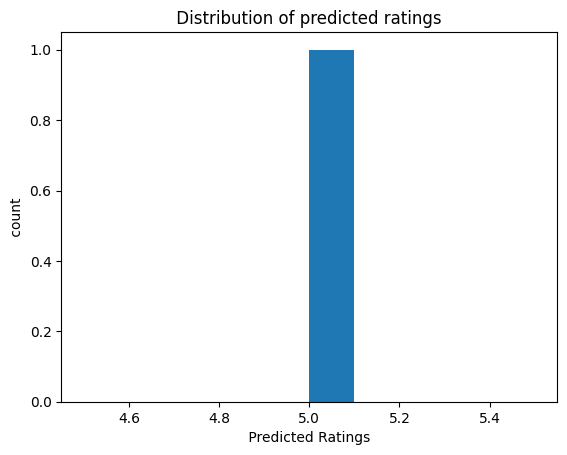

In [14]:
# Seeing the prediction visualization  # seein only one value for sample

predictions = model.test ( testset )

predicted_values = []

for pred in predictions:

    predicted_values.append ( pred.est )

    plt.hist (predicted_values)

    plt.xlabel ( " Predicted Ratings " )

    plt.ylabel ( " count " )

    plt.title ( " Distribution of predicted ratings " )

    plt.show ()

    break


Excellent 🔥 These are exactly the questions you should be asking. You’ve hit two important concepts:

1. Why all unseen users get 4.41


2. How to interpret the histogram



I'll use your output directly.


---

1️⃣ Why every unseen user got exactly 4.41

You tested:

User:1000 Movie:50 → 4.41
User:2000 Movie:50 → 4.41
User:1489 Movie:50 → 4.41
User:945 Movie:50 → 4.41

You expected:

different users → different ratings

but got the same value.

Let's understand.


---

Your dataset has:

943 users

Valid users:

1 → 943

You tested:

1000
1489
2000

These users don't exist.

So SVD thinks:

"I've never seen these users during training"

Then it cannot learn:

their preferences

their taste pattern

latent features


So it falls back to:

movie average + default bias

Essentially:

Unknown User
      ↓
Use average estimate

That average estimate for Movie 50 became:

4.41

Hence:

User1000 → 4.41
User2000 → 4.41
User1489 → 4.41


---

Think of Netflix:

New user signs up

Netflix initially knows:

nothing about you

So it recommends:

popular movies

trending content


because:

no personalization exists yet

This is exactly the same thing.


---

Why user 945 also got 4.41 ?

Interesting catch 👀

Dataset ends at:

943

So:

945

also doesn't exist.

Therefore:

945 → unseen user

same logic.


---

2️⃣ Understanding your histogram

Your graph:

x-axis → predicted ratings

y-axis → number of predictions



---

You got something like:

Count
300 |
    |
250 |                ███
    |             ███████
200 |           ██████████
    |        ██████████████
100 |      █████████████████
    |________________________________
      1    2    3    4    5

            Predicted Rating


---

Let's read this slowly.

Most predictions are around:

3 → 4

particularly:

3.5–4


---

Meaning:

Model says:

"I am moderately confident users may like these"


---

Why aren't there many 1s and 5s?

You might think:

Movie ratings are from 1–5

So why not many predictions near 1 or 5?

Because SVD behaves cautiously.

The model avoids:

extreme predictions

unless there is strong evidence.

Instead of:

5

it says:

4.2
4.1
3.8

Instead of:

1

it says:

2.1
2.3


---

This is called:

Regression toward the mean

Simple meaning:

When uncertain,
move toward average values


---

Your graph tells us:

Few predictions near 1–2

Meaning:

model rarely strongly dislikes movies


---

Most predictions near 3–4

Meaning:

model generally predicts moderate preferences


---

Few predictions near 5

Meaning:

model only becomes very confident occasionally


---

One experiment for you (very useful)

Run:

predictions = model.test(testset)

predicted_values=[]

for pred in predictions:
    predicted_values.append(pred.est)

print("Min:",min(predicted_values))
print("Max:",max(predicted_values))
print("Mean:",sum(predicted_values)/len(predicted_values))

Check:

minimum prediction

maximum prediction

average prediction


Then compare with your histogram.

You'll suddenly see:

"Ohhh the graph is basically centered around the average prediction"

which is the hidden story behind your visualization.

This was actually a very good observation. You’re beginning to read model behavior instead of just running code.



In [15]:
predictions = model.test(testset)

predicted_values=[]

for pred in predictions:
    predicted_values.append(pred.est)

print("Min:",min(predicted_values))
print("Max:",max(predicted_values))
print("Mean:",sum(predicted_values)/len(predicted_values))


Min: 1
Max: 5
Mean: 3.5337528890261485


In [16]:
predictions = model.test(testset)

strong_like = 0
strong_dislike = 0
moderate = 0

for pred in predictions:

    if pred.est >= 4.5:
        strong_like += 1

    elif pred.est <= 2:
        strong_dislike += 1

    else:
        moderate += 1

print("Strong Like:", strong_like)
print("Strong Dislike:", strong_dislike)
print("Moderate:", moderate)


Strong Like: 957
Strong Dislike: 310
Moderate: 18733
